In [1]:
import torch

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
B = torch.zeros([27,27])
chrs = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chrs)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
for w in words:
    w = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(w,w[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        B[ix1,ix2] += 1


In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

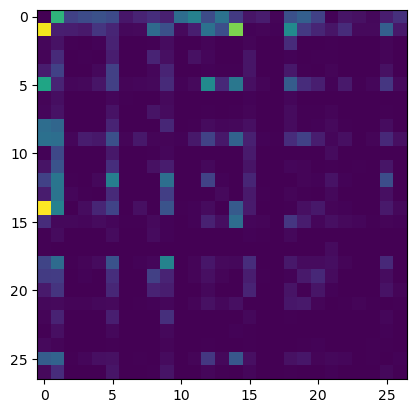

In [6]:
plt.imshow(B)
plt.show()

In [7]:
P = B/B.sum(1,keepdim=True)


Rule for broadcasting is that you allign dimensions to the right so if keepdim = False

You get B.sum(1).shape = 27

 27 x 27
 27 - this is moved to the right to match

 27 x 27
      27 - IT IS BROADCASTABLE BUT WRONG

Internally if there is no value you add a 1 and then that is broadcast to match the dimension so you will be dividing by a 1x27 not a 27x1. CAREFUL

In [8]:
# We don't want to create a new tensor P(less memory used), we prefer to use:
B /= B.sum(1,keepdim=True)


In [9]:
B[0].sum()

tensor(1.)

In [10]:

for i in range(10):
    ix = 0
    name = []
    while True:
        ltr_ix = torch.multinomial(B[ix], num_samples=1,replacement=True).item()
        name.append(itos[ltr_ix])
        ix = ltr_ix
        if ix == 0:
            break
    print(''.join(name))


ai.
rurar.
hsonai.
n.
pon.
sar.
morkeraria.
avicholinchel.
a.
klanikuitanes.


Truncating is done with ":.4f" this is for f string, gives 4 digits.

In [11]:
for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(w,w[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        print(f'{ch1}{ch2}: {prob:.4f}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


If you had a probability distribution with equal likelihood 1/27, your model doesn't really do much. But if you see that you have distributions which are highly likely that means your model is seeing and learning. In a good model you want the probability to be close to 1, because then the model is correctly predicting what is going to come next.

In [12]:
# Maximum likelihood estimation:
# likelihood is the product of all probabilities! The product of these should be high if you have a good model
# Because the product of them would be a small number due to the fact that the numbers are between 0 and 1, you usually work with the log likelihood.
log_likelihood = 0.0
n = 0
for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(w,w[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n +=1
        print(f'{ch1}{ch2}: {prob:.4f}, {logprob:.4f}')
print(f'log_likelihood is {log_likelihood:.4f}') # When all the probabilities are high the value will be close to 0 and when the probabilities are lower the value goes lower and lower.
nll = -log_likelihood
print(f'nll: {nll:.4f}')
nll_norm = nll/n
print(f'normalized nll: {nll_norm}') # We get the average log likelihood

.e: 0.0478, -3.0408
em: 0.0377, -3.2793
mm: 0.0253, -3.6772
ma: 0.3899, -0.9418
a.: 0.1960, -1.6299
.o: 0.0123, -4.3982
ol: 0.0780, -2.5508
li: 0.1777, -1.7278
iv: 0.0152, -4.1867
vi: 0.3541, -1.0383
ia: 0.1381, -1.9796
a.: 0.1960, -1.6299
.a: 0.1377, -1.9829
av: 0.0246, -3.7045
va: 0.2495, -1.3882
a.: 0.1960, -1.6299
log_likelihood is -38.7856
nll: 38.7856
normalized nll: 2.424102306365967
